In [57]:
import os

os.chdir('/home/bill/GitHub/wps-research/data/bill')

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
from fire_mapping.raster import Raster, htrim_3d

In [60]:
image_file = 'test/S2B_MSIL1C_20251009T192229_N0511_R099_T09UYU_20251009T225450_20m.bin'

In [61]:
band_list = [10, 11, 12]

In [62]:
image = Raster(image_file).read_bands(band_lst=band_list)
x_size, y_size = image.shape[0], image.shape[1]

In [63]:
band_names = [Raster(image_file).band_info_list[i-1] for i in band_list]
band_names

['B11_diff', 'B9_diff', 'B8_diff']

In [64]:
X = image.reshape(-1, len(band_list))

X = np.nan_to_num(X, nan=0.0)

**KNN**

KNN band-pair separation  |  3 bands  →  3 pairs
Keeping top N=6  |  n_neighbors=20  |  fit_samples=20,000  |  backend=cuML/GPU
Ranking by: Silhouette (unsupervised, KMeans pseudo-labels)
─────────────────────────────────────────────────────────────────
  [1/3]    B11_diff × B9_diff       score=0.6369
  [2/3]    B11_diff × B8_diff       score=0.6359
  [3/3]     B9_diff × B8_diff       score=0.7938

All 3 pairs done. Top-6 selected.

  Rank  Band Pair                     Silhouette  Bar
─────────────────────────────────────────────────────────────────
  1        B9_diff × B8_diff               0.7938  ███████████████████████████░░░
  2       B11_diff × B9_diff               0.6369  █████████████████████████░░░░░
  3       B11_diff × B8_diff               0.6359  █████████████████████████░░░░░
─────────────────────────────────────────────────────────────────


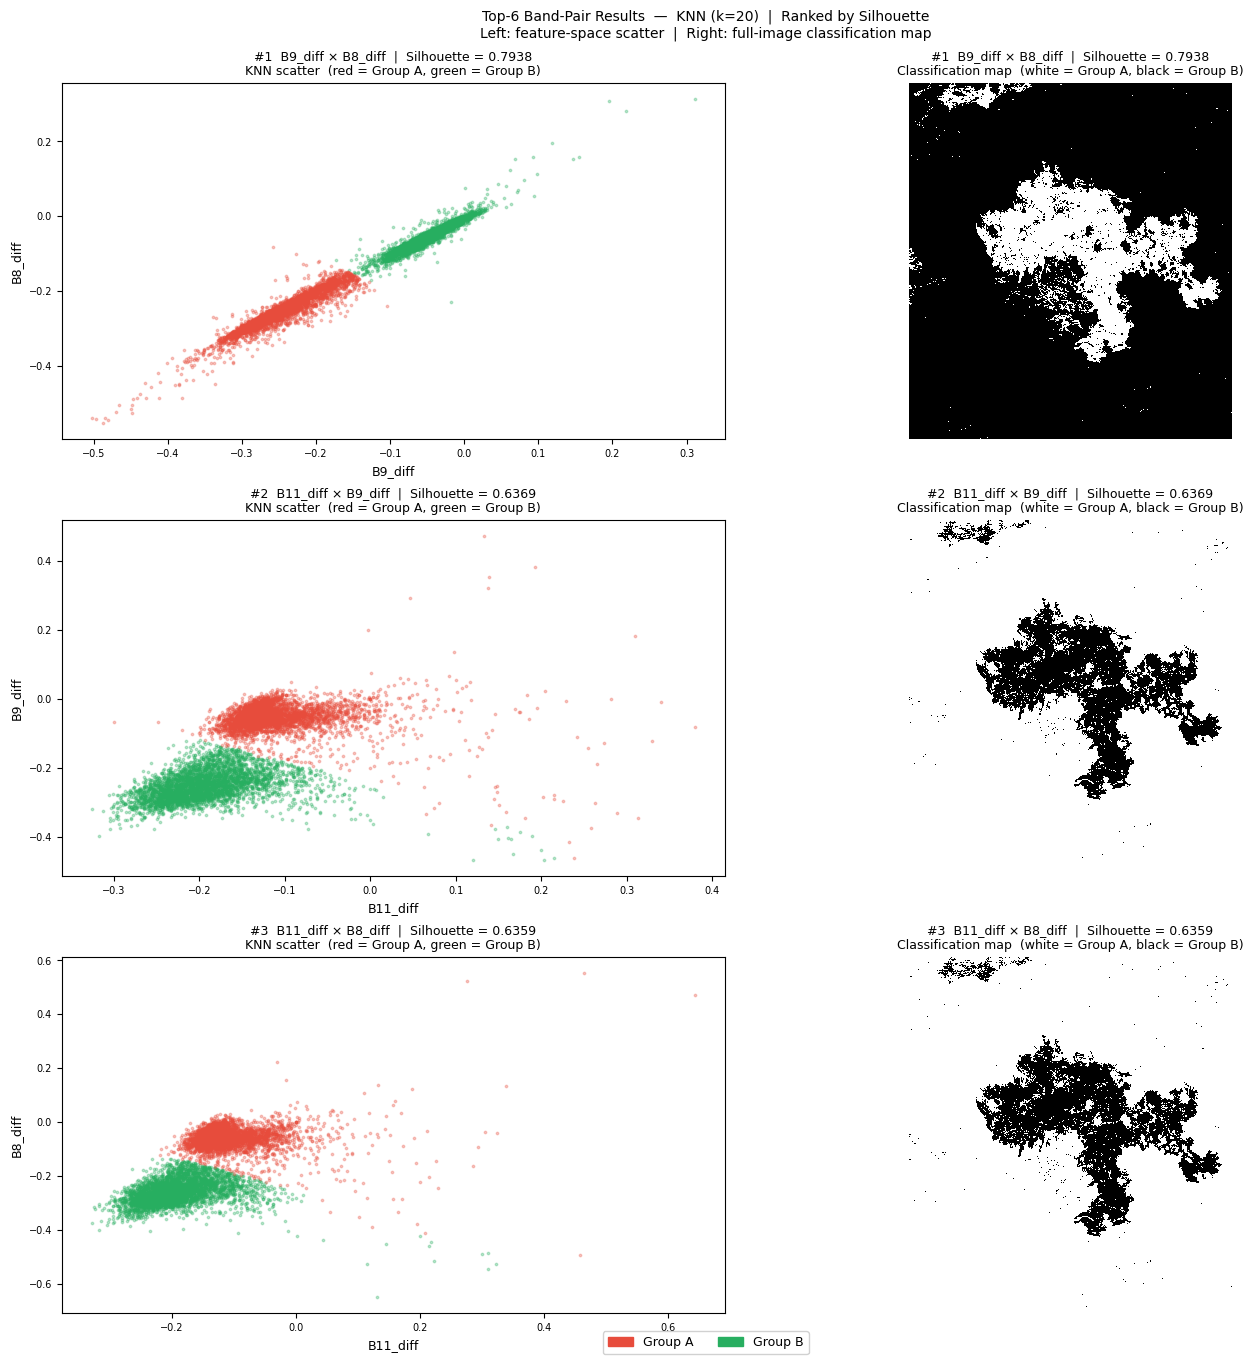

In [67]:
# ═════════════════════════════════════════════════════════════════════════════
#  KNN Top-N Band Pair Separation
# ─────────────────────────────────────────────────────────────────────────────
#  For every band pair:
#    • Subsample pixels for fitting (cuML operates on GPU memory)
#    • If y given   → train cuML KNN on true labels, rank by AUC
#    • If y is None → cuML KMeans(k=2) pseudo-labels, rank by silhouette
#    • Predict ALL pixels on GPU for the full classification map
#    • Keep top-N pairs in a min-heap (O(pairs · log N))
#
#  Usage
#  ─────
#  from knn_top_separations import knn_top_separations
#
#  top = knn_top_separations(
#      X             = X,           # (n_pixels, n_bands)  float
#      feature_names = band_list,   # list[str]
#      N             = 6,
#      n_neighbors   = 15,
#      x_size        = x_size,
#      y_size        = y_size,
#  )
# ═════════════════════════════════════════════════════════════════════════════

import heapq
import itertools

import cupy as cp
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from cuml.cluster        import KMeans
from cuml.neighbors      import KNeighborsClassifier
from cuml.preprocessing  import StandardScaler
from sklearn.metrics     import roc_auc_score, silhouette_score


# ─────────────────────────────────────────────────────────────────────────────
#  Internal helpers
# ─────────────────────────────────────────────────────────────────────────────

def _subsample_idx(n_pixels, n_samples, rng):
    if n_pixels > n_samples:
        return rng.choice(n_pixels, n_samples, replace=False)
    return np.arange(n_pixels)


def _get_labels_and_score(X2_fit, y_fit, n_neighbors, random_state, use_auc):
    """
    Fit cuML KNN on the subsample and return (knn, labels, score).
    All heavy computation happens on the GPU via cupy arrays.

    If use_auc  → supervised: labels = y_fit, score = AUC
    If not      → unsupervised: labels from cuML KMeans(k=2), score = silhouette
    """
    # Move to GPU
    X2_gpu = cp.asarray(X2_fit, dtype=cp.float32)

    if use_auc:
        labels_gpu = cp.asarray(y_fit, dtype=cp.int32)
    else:
        km         = KMeans(n_clusters=2, random_state=random_state, max_iter=300)
        labels_gpu = cp.asarray(
            km.fit_predict(X2_gpu), dtype=cp.int32
        )

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X2_gpu, labels_gpu)

    if use_auc:
        proba  = cp.asnumpy(knn.predict_proba(X2_gpu))[:, 1]
        labels_np = cp.asnumpy(labels_gpu)
        score  = roc_auc_score(labels_np, proba)
        score  = max(score, 1.0 - score)
    else:
        pred_gpu  = knn.predict(X2_gpu)
        pred_np   = cp.asnumpy(pred_gpu)
        labels_np = cp.asnumpy(labels_gpu)
        if len(np.unique(pred_np)) < 2:
            score = 0.0
        else:
            score = float(silhouette_score(
                X2_fit, pred_np,
                sample_size=min(5_000, len(pred_np)),
                random_state=random_state,
            ))

    return knn, labels_gpu, score


# ─────────────────────────────────────────────────────────────────────────────
#  Main function
# ─────────────────────────────────────────────────────────────────────────────

def knn_top_separations(
    X,
    feature_names,
    y              = None,
    N              = 6,
    n_neighbors    = 15,
    n_fit_samples  = 20_000,
    max_scatter    = 4_000,
    random_state   = 42,
    show_ellipses  = False,
    show_bar_chart        = True,
    x_size                = None,
    y_size                = None,
    save_classifications  = True,
):
    """
    Stream KNN over all band pairs and retain the top-N by separation score.

    Parameters
    ----------
    X              : (n_pixels, n_bands) float  — full flattened image
    feature_names  : list[str]           — band names, len == n_bands
    y              : (n_pixels,) int     — optional binary labels {0,1}.
                     If given, ranks by AUC. If None, uses KMeans pseudo-labels
                     and ranks by silhouette score.
    N              : int  — top pairs to keep                  (default 6)
    n_neighbors    : int  — K for KNeighborsClassifier         (default 15)
    n_fit_samples  : int  — pixels used for fitting            (default 20_000)
    max_scatter    : int  — max scatter points per group       (default 4_000)
    random_state   : int  — reproducibility seed
    show_ellipses  : bool — not used (kept for API compatibility)
    show_bar_chart : bool — show summary AUC/silhouette bar chart (default True)
    x_size         : int  — image rows; required for map panel
    y_size         : int  — image cols; required for map panel
    n_jobs         : int  — parallel workers (-1 = all cores)

    Returns
    -------
    list[dict]  length N, best → worst, each dict has:
        rank, band_i, band_j, name_i, name_j, score, knn
    """

    # ── Validate ──────────────────────────────────────────────────────────────
    X     = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2-D (n_pixels × n_bands), got {X.shape}")
    if len(feature_names) != X.shape[1]:
        raise ValueError("len(feature_names) must equal X.shape[1]")
    if x_size is None or y_size is None:
        raise ValueError("x_size and y_size are required for the classification map.")

    use_auc = y is not None
    if use_auc:
        y_arr = np.asarray(y, dtype=int).ravel()
        if len(y_arr) != X.shape[0]:
            raise ValueError("len(y) must equal X.shape[0]")
    else:
        y_arr = None

    n_pixels, n_bands = X.shape
    all_pairs         = list(itertools.combinations(range(n_bands), 2))
    total             = len(all_pairs)

    # ── Subsample index (shared across all pairs) ─────────────────────────────
    rng      = np.random.default_rng(random_state)
    fit_idx  = _subsample_idx(n_pixels, n_fit_samples, rng)
    y_fit    = y_arr[fit_idx] if use_auc else None

    print(f"KNN band-pair separation  |  {n_bands} bands  →  {total} pairs")
    print(f"Keeping top N={N}  |  n_neighbors={n_neighbors}  |  "
          f"fit_samples={len(fit_idx):,}  |  backend=cuML/GPU")
    print(f"Ranking by: {'AUC (supervised)' if use_auc else 'Silhouette (unsupervised, KMeans pseudo-labels)'}")
    print("─" * 65)

    # ── Parallel worker ───────────────────────────────────────────────────────
    def _process_pair(i, j):
        X2_fit    = X[fit_idx][:, [i, j]].astype(np.float32)
        X2_fit_gpu = cp.asarray(X2_fit)

        # Standardise on GPU so KNN distances are fair
        scaler    = StandardScaler()
        X2_fit_sc = cp.asnumpy(scaler.fit_transform(X2_fit_gpu))

        knn, _, score = _get_labels_and_score(
            X2_fit_sc, y_fit, n_neighbors, random_state, use_auc
        )

        return dict(
            band_i = i,  band_j = j,
            name_i = feature_names[i],  name_j = feature_names[j],
            score  = score,
            knn    = knn,
            scaler = scaler,
        )

    # ── Run pairs sequentially — GPU handles parallelism internally ──────────
    all_entries = []
    for step, (i, j) in enumerate(all_pairs):
        entry = _process_pair(i, j)
        all_entries.append(entry)
        if (step + 1) % max(1, total // 10) == 0 or (step + 1) == total:
            print(f"  [{step+1}/{total}]  "
                  f"{feature_names[i]:>10} × {feature_names[j]:<12}  "
                  f"score={entry['score']:.4f}")

    # ── Build top-N heap ──────────────────────────────────────────────────────
    heap = []
    for counter, entry in enumerate(all_entries):
        s = entry['score']
        if len(heap) < N:
            heapq.heappush(heap, (s, counter, entry))
        elif s > heap[0][0]:
            heapq.heapreplace(heap, (s, counter, entry))

    print(f"\nAll {total} pairs done. Top-{N} selected.\n")

    # ── Sort best → worst ─────────────────────────────────────────────────────
    top_results = sorted(heap, key=lambda x: x[0], reverse=True)
    top_results = [e for _, _, e in top_results]
    for rank, e in enumerate(top_results, 1):
        e["rank"] = rank

    # ── Summary table ─────────────────────────────────────────────────────────
    score_label = "AUC" if use_auc else "Silhouette"
    bar_max     = 30
    print(f"  {'Rank':<6}{'Band Pair':<28}{score_label:>12}  Bar")
    print("─" * 65)
    for e in top_results:
        fill    = e["score"] if use_auc else (e["score"] + 1) / 2   # sil ∈ [-1,1] → [0,1]
        bar_len = int(round(fill * bar_max))
        bar     = "█" * bar_len + "░" * (bar_max - bar_len)
        print(f"  {e['rank']:<6}{e['name_i']:>10} × {e['name_j']:<16}"
              f"{e['score']:>12.4f}  {bar}")
    print("─" * 65)

    # ─────────────────────────────────────────────────────────────────────────
    #  Plots
    # ─────────────────────────────────────────────────────────────────────────
    n_plots         = len(top_results)
    # Dict keyed by rank (1-based) storing the 2D binary classification map
    classification_maps = {}
    COL_A     = "#e74c3c"   # red
    COL_B     = "#27ae60"   # green
    _rng_plot = np.random.default_rng(random_state + 1)

    # ── Optional bar chart ────────────────────────────────────────────────────
    if show_bar_chart:
        scores     = [e["score"] for e in top_results]
        labels_bar = [f"#{e['rank']}\n{e['name_i']}×{e['name_j']}"
                      for e in top_results]
        colors_bar = plt.cm.RdYlGn(np.linspace(0.25, 0.85, n_plots))[::-1]

        fig0, ax0  = plt.subplots(figsize=(max(6, n_plots * 1.2), 3.5))
        bars       = ax0.bar(range(n_plots), scores, color=colors_bar,
                             width=0.6, zorder=3)
        ax0.set_xticks(range(n_plots))
        ax0.set_xticklabels(labels_bar, fontsize=8)
        ax0.set_ylabel(score_label)
        ax0.set_title(
            f"Top-{N} Band Pair Separations  (KNN, k={n_neighbors})  "
            f"— ranked by {score_label}"
        )
        ax0.grid(axis="y", alpha=0.3, zorder=0)

        if use_auc:
            ax0.set_ylim(max(0.45, min(scores) - 0.05), 1.01)
            ax0.axhline(0.75, color="orange", lw=0.8, ls=":", label="0.75")
            ax0.axhline(0.90, color="green",  lw=0.8, ls=":", label="0.90")
            ax0.legend(fontsize=8, loc="lower right")
        else:
            ax0.set_ylim(max(-0.05, min(scores) - 0.05),
                         min(1.01,  max(scores) + 0.05))
            ax0.axhline(0.0, color="grey", lw=0.8, ls="--", label="no separation (0)")
            ax0.legend(fontsize=8, loc="lower right")

        for bar, s in zip(bars, scores):
            ax0.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f"{s:.4f}", ha="center", va="bottom", fontsize=7)

        plt.tight_layout()
        plt.show()

    # ── Paired scatter + map (one row per pair) ───────────────────────────────
    fig, axes = plt.subplots(
        n_plots, 2,
        figsize=(14, 4.5 * n_plots),
        squeeze=False,
        constrained_layout=True,
    )

    for e in top_results:
        row    = e["rank"] - 1
        ax_sc  = axes[row][0]
        ax_map = axes[row][1]

        i, j   = e["band_i"], e["band_j"]
        X2     = X[:, [i, j]]

        # Scale + predict on GPU, bring result back to CPU for plotting
        X2_gpu = cp.asarray(X2.astype(np.float32))
        X2_sc  = e["scaler"].transform(X2_gpu)
        pred   = cp.asnumpy(e["knn"].predict(X2_sc)).astype(np.uint8)

        # Save the 2D map keyed by rank so the caller can use it later
        if save_classifications:
            classification_maps[e["rank"]] = pred.reshape(x_size, y_size)

        # ── Left: scatter coloured by KNN assignment ──────────────────────
        idx_a = np.where(pred == 1)[0]
        idx_b = np.where(pred == 0)[0]
        if len(idx_a) > max_scatter:
            idx_a = _rng_plot.choice(idx_a, max_scatter, replace=False)
        if len(idx_b) > max_scatter:
            idx_b = _rng_plot.choice(idx_b, max_scatter, replace=False)

        ax_sc.scatter(X2[idx_b, 0], X2[idx_b, 1], s=3, alpha=0.30,
                      color=COL_B, rasterized=True, label="Group B")
        ax_sc.scatter(X2[idx_a, 0], X2[idx_a, 1], s=3, alpha=0.30,
                      color=COL_A, rasterized=True, label="Group A")

        ax_sc.set_xlabel(e["name_i"], fontsize=9)
        ax_sc.set_ylabel(e["name_j"], fontsize=9)
        ax_sc.set_title(
            f"#{e['rank']}  {e['name_i']} × {e['name_j']}  |  "
            f"{score_label} = {e['score']:.4f}\n"
            f"KNN scatter  (red = Group A, green = Group B)",
            fontsize=9,
        )
        ax_sc.tick_params(labelsize=7)

        # ── Right: grayscale classification map ───────────────────────────
        ax_map.imshow(
            pred.reshape(x_size, y_size),
            cmap="gray", vmin=0, vmax=1,
            interpolation="nearest",
        )
        ax_map.set_title(
            f"#{e['rank']}  {e['name_i']} × {e['name_j']}  |  "
            f"{score_label} = {e['score']:.4f}\n"
            f"Classification map  (white = Group A, black = Group B)",
            fontsize=9,
        )
        ax_map.axis("off")

    # Shared legend
    patch_a = mpatches.Patch(color=COL_A, label="Group A")
    patch_b = mpatches.Patch(color=COL_B, label="Group B")
    fig.legend(handles=[patch_a, patch_b], loc="lower center",
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.01 / n_plots),
               framealpha=0.9)
    fig.suptitle(
        f"Top-{N} Band-Pair Results  —  KNN (k={n_neighbors})  |  "
        f"Ranked by {score_label}\n"
        f"Left: feature-space scatter  |  Right: full-image classification map",
        fontsize=10,
    )
    plt.show()

    if save_classifications:
        return top_results, classification_maps
    return top_results


# ─────────────────────────────────────────────────────────────────────────────
#  Usage
# ─────────────────────────────────────────────────────────────────────────────
#
#  Unsupervised (no labels):
#
#  top = knn_top_separations(
#      X              = X,
#      feature_names  = band_list,
#      N              = 6,
#      n_neighbors    = 15,
#      x_size         = x_size,
#      y_size         = y_size,
#  )
#
#  Supervised (with labels, ranked by AUC):
#
top, map = knn_top_separations(
     X              = X,
     feature_names  = band_names,
     N              = 6,
     n_neighbors    = 20,
     x_size         = x_size,
     y_size         = y_size,
     show_bar_chart = False,   # hide the summary bar chart
 )